<a href="https://colab.research.google.com/github/devayyan137/ARCH-Technologies---Machine-Learning-Internship-Tasks/blob/main/Task_2_MNIST_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

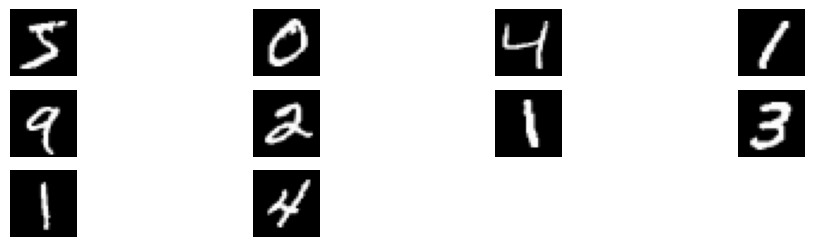

In [27]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')
plt.show()

In [16]:

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8575 - loss: 2.1056 - val_accuracy: 0.9137 - val_loss: 0.4648
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9222 - loss: 0.3770 - val_accuracy: 0.9365 - val_loss: 0.2996
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9405 - loss: 0.2373 - val_accuracy: 0.9335 - val_loss: 0.2778
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9503 - loss: 0.1822 - val_accuracy: 0.9477 - val_loss: 0.2021
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9553 - loss: 0.1638 - val_accuracy: 0.9523 - val_loss: 0.1849
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9616 - loss: 0.1370 - val_accuracy: 0.9427 - val_loss: 0.2271
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9644 - loss: 0.1289 - val_accuracy: 0.9567 - val_loss: 0.1701
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9692 - loss: 0.1099 

In [24]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Precision Score: {prec*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 95.98%
Precision Score: 96.03%
F1 Score: 95.98%


In [19]:
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.99      0.98      0.98      1135
           2       0.98      0.94      0.96      1032
           3       0.93      0.97      0.95      1010
           4       0.98      0.92      0.95       982
           5       0.97      0.96      0.96       892
           6       0.97      0.97      0.97       958
           7       0.96      0.97      0.96      1028
           8       0.94      0.95      0.94       974
           9       0.92      0.96      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



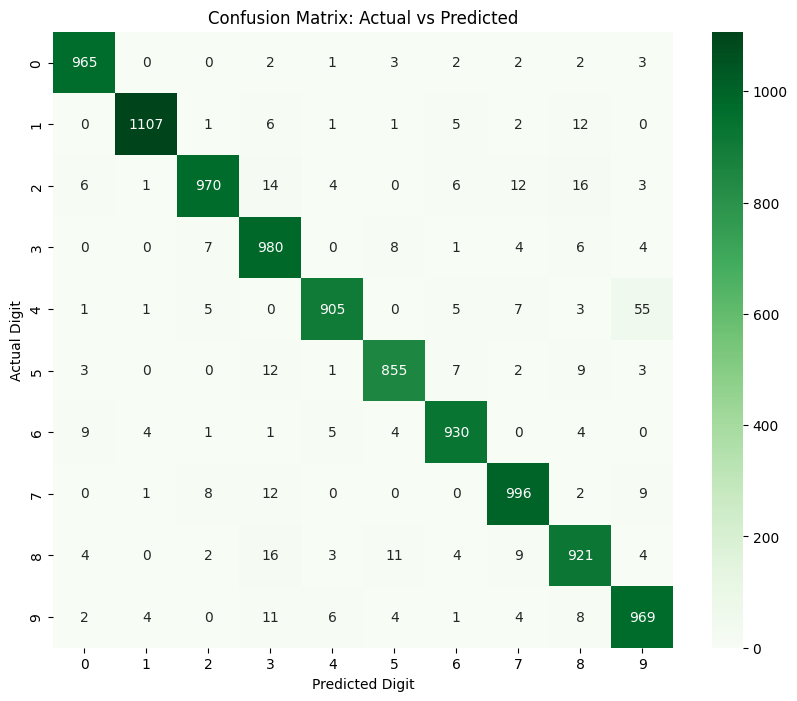

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Actual vs Predicted")
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Real Digit: 8
Model Prediction: 8


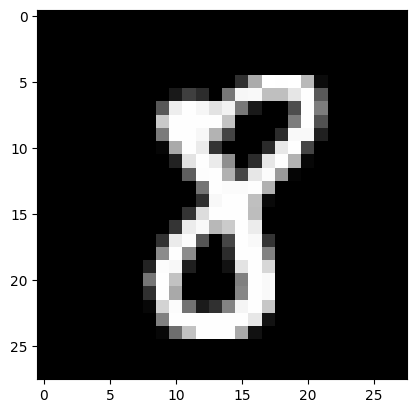

In [29]:
def predict_digit(index):
    img = X_test[index]
    prediction = model.predict(img.reshape(1, 28, 28))
    print(f"Real Digit: {y_test[index]}")
    print(f"Model Prediction: {np.argmax(prediction)}")
    plt.imshow(img, cmap='gray')
    plt.show()
predict_digit(134)